# From picks to a catalog with GaMMA

Notebook 05 produced a pile of picks: a phase name, a time, and the station
it came from. Notebook 03 produced a much bigger pile from the fibre. A pile
of picks is not a catalog. Turning one into the other means deciding **which
picks belong to the same earthquake**, and then where and when that
earthquake was — association and location, in one step.

[GaMMA](https://github.com/AI4EPS/GaMMA) does that by treating the picks as a
Gaussian mixture in which each component is an earthquake, and the travel
time from a hypocentre is the mean. It is a good fit for DAS precisely
because it does not care how many "stations" there are: a channel is a point
that recorded a phase at a time, exactly like a seismometer. So the cable and
the network go into the same association, together, in one run.

```{note}
The install is `pip install git+https://github.com/AI4EPS/GaMMA.git`, and
mind the name: the distribution is called `gmma` but you `import gamma`. The
package on PyPI called `GaMMA` is something else entirely.
```

In [1]:
import numpy as np
import pandas as pd
import pyproj
from obspy import read_inventory

import xdas as xd
from gamma.utils import association

## The two tables GaMMA wants

A **stations** table, positioned in a local Cartesian frame in kilometres,
and a **picks** table keyed by the same station ids. Everything that recorded
something — six seismometers and a few hundred metres-apart fibre channels —
ends up in those same two tables.

In [2]:
picks = pd.read_csv("outputs/station_picks.csv", parse_dates=["time"])
das = pd.read_csv("outputs/picks.csv", parse_dates=["time"])
inventory = read_inventory("data/stations/stations.xml")

rows = [
    (f"{net.code}.{sta.code}", sta.latitude, sta.longitude, sta.elevation)
    for net in inventory
    for sta in net
]
stations = pd.DataFrame(
    rows, columns=["id", "latitude", "longitude", "elevation"]
).drop_duplicates("id")

An azimuthal-equidistant projection centred on the network turns degrees
into kilometres, which is what the travel-time calculation needs:

In [3]:
proj = pyproj.Proj(
    proj="aeqd",
    lat_0=stations["latitude"].mean(),
    lon_0=stations["longitude"].mean(),
    units="km",
)
stations["x(km)"], stations["y(km)"] = proj(
    stations["longitude"].values, stations["latitude"].values
)
stations["z(km)"] = -stations["elevation"] / 1000.0
stations = stations[stations["id"].isin(set("C1." + picks["station"]))]
stations

,id,latitude,longitude,elevation,x(km),y(km),z(km)
9,C1.CO01,-29.97730,-70.09390,2157.0,98.807396,89.672232,-2.157
10,C1.CO02,-31.20370,-71.00030,1190.0,11.188702,-45.847080,-1.190
11,C1.CO03,-30.83890,-70.68910,1003.0,41.001996,-5.474415,-1.003
12,C1.CO04,-32.04330,-70.97470,2401.0,13.507541,-138.944982,-2.401
13,C1.CO05,-29.91864,-71.23841,101.0,-11.656478,96.616871,-0.101
18,C1.VA06,-32.56117,-71.29765,80.0,-16.902025,-196.377769,-0.080


### Every picked channel is a station too

The fibre needs the same three columns, which means knowing where each
channel physically is. That information already travelled here: it was
attached during consolidation (notebook 01) from the real cable geometry.
Pull it off `outputs/singlecable.nc` and interpolate it onto whichever
channels the picker actually fired on:

In [4]:
cable = xd.open("outputs/singlecable.nc")

channels = np.sort(das["distance"].unique())
latitude = np.interp(
    channels, cable["distance"].values, cable["latitude"].values, left=np.nan, right=np.nan
)
longitude = np.interp(
    channels, cable["distance"].values, cable["longitude"].values, left=np.nan, right=np.nan
)

das_stations = pd.DataFrame(
    {"id": [f"DAS.{d:.0f}" for d in channels], "latitude": latitude, "longitude": longitude, "elevation": 0.0}
).dropna(subset=["latitude", "longitude"])
das_stations["x(km)"], das_stations["y(km)"] = proj(
    das_stations["longitude"].values, das_stations["latitude"].values
)
das_stations["z(km)"] = 0.0  # the fiber sits at the surface

print(f"{len(das_stations)} of {len(channels)} picked channels fall on the surveyed 102 km of cable")

173 of 204 picked channels fall on the surveyed 102 km of cable


The channels past 102 km, where the cable was never surveyed, drop out here:
a coordinate is only as good as the survey behind it, and a pick without one
cannot be associated.

```{warning}
Drop them yourself, and keep the stations table down to the columns you
mean. GaMMA discards any pick whose station row holds a `NaN` in **any**
column, so one extra column that is only filled for the fibre — a channel
distance, say — silently throws away every land station and every pick that
came with it, without an error and without changing the number of events.
```

## The picks table

Four columns under GaMMA's own names — the station `id`, the `timestamp`,
the phase `type` in lower case, and the model's confidence as `prob` — for
the network and for the fibre alike:

In [5]:
gamma_picks = pd.DataFrame(
    {
        "id": picks["network"] + "." + picks["station"],
        "timestamp": picks["time"],
        "type": picks["phase"].str.lower(),
        "prob": picks["value"],
    }
)

das_gamma_picks = pd.DataFrame(
    {
        "id": das["distance"].map(lambda d: f"DAS.{d:.0f}"),
        "timestamp": das["time"],
        "type": das["phase"].str.lower(),
        "prob": das["value"],
    }
)
das_gamma_picks = das_gamma_picks[das_gamma_picks["id"].isin(das_stations["id"])]
gamma_picks

,id,timestamp,type,prob
0,C1.CO01,2023-11-03 12:27:14.100000,p,0.698469
1,C1.CO01,2023-11-03 12:27:30.820000,s,0.780952
2,C1.CO02,2023-11-03 12:27:14.500000,p,0.715876
3,C1.CO02,2023-11-03 12:27:33.460000,s,0.420162
4,C1.CO03,2023-11-03 12:27:11.700000,p,0.911087
5,C1.CO03,2023-11-03 12:27:27.840000,s,0.536183
6,C1.CO04,2023-11-03 12:27:27.129998,p,0.482439
7,C1.CO04,2023-11-03 12:27:53.549998,s,0.363163
8,C1.CO05,2023-11-03 12:26:57.420000,p,0.967788
9,C1.CO05,2023-11-03 12:27:03.020000,s,0.860738


### Thinning the fibre

The cable brings thirty times more picks than the network, and neighbouring
channels 500 m apart see very nearly the same arrival: the picks are hugely
redundant. GaMMA's cost grows with their number — a real deployment has tens
of thousands of channels, not a hundred and seventy — so the association
gets a thinned cable and the figures keep the whole of it.

Thin it **by distance**, one channel every few kilometres, rather than by
drawing picks at random. Both cut the count, but a random draw clumps in
some places and leaves gaps in others, and it can keep a channel's P and
drop its S; a regular decimation keeps the full 100 km aperture, an even
sampling of the moveout, and both phases wherever it keeps a channel. One
channel every 5 km is a tenth of the picks here.

How hard to thin is a real choice, not a free one: `spacing` is the knob,
and a coarser cable gives the land stations proportionally more weight in
the fit — visible further down in which of their picks survive.

In [6]:
spacing = 5.0  # km between the channels we keep

along = das_stations["id"].str.split(".").str[1].astype(float) / 1000  # km along the cable
keep = das_stations.loc[~(along // spacing).duplicated(), "id"]

sample = das_gamma_picks[das_gamma_picks["id"].isin(keep)]
held_out = das_gamma_picks.drop(sample.index)

combined_stations = pd.concat([stations, das_stations], ignore_index=True)
combined_picks = pd.concat([gamma_picks, sample], ignore_index=True)

print(
    f"one channel every {spacing:.0f} km keeps {len(keep)} of {len(das_stations)} channels, "
    f"{len(sample)} of {len(das_gamma_picks)} fibre picks ({100 * len(sample) / len(das_gamma_picks):.0f}%)"
)
print(
    f"{len(gamma_picks)} station picks + {len(sample)} fibre picks "
    f"= {len(combined_picks)} picks over {len(combined_stations)} positions"
)

one channel every 5 km keeps 20 of 173 channels, 35 of 362 fibre picks (10%)
12 station picks + 35 fibre picks = 47 picks over 179 positions


## A velocity model

Two constant velocities are not enough here. The network spans 300 km, and
beyond about 150 km the first P arrival is no longer a crustal wave but Pn,
refracted along the Moho, so a single 6 km/s cannot place P and S both in
the right spot. Use a real 1-D profile instead — the one
[Marot et al. (2014)](https://doi.org/10.1093/gji/ggu355) inverted for
central Chile, 23 layers from 5 km above sea level to 215 km down, with a
vp/vs of 1.76:

In [7]:
velocity_model = pd.read_csv("data/velocity/marot2014.csv")  # metres and m/s
velocity_model /= 1000  # GaMMA works in km and km/s
velocity_model.head()

,depth,p,s
0,-5.0,4.900,2.7841
1,5.0,6.100,3.4659
2,15.0,6.600,3.7500
3,25.0,6.920,3.9312
4,35.0,7.141,4.0574


GaMMA takes such a profile under `eikonal`: it solves the eikonal equation
once on an (r, z) grid and interpolates travel times out of the result, so
the moveout bends the way a layered earth makes it bend. Everything else is
the search volume and the thresholds that decide when a cluster of picks is
convincing enough to be called an earthquake:

In [8]:
xlim = (combined_stations["x(km)"].min() - 50, combined_stations["x(km)"].max() + 50)
ylim = (combined_stations["y(km)"].min() - 50, combined_stations["y(km)"].max() + 50)
zlim = (0.0, 60.0)

config = {
    "dims": ["x(km)", "y(km)", "z(km)"],
    "x(km)": xlim,
    "y(km)": ylim,
    "z(km)": zlim,
    "bfgs_bounds": (xlim, ylim, zlim, (None, None)),
    "use_dbscan": True,
    "dbscan_eps": 25.0,
    "dbscan_min_samples": 3,
    "use_amplitude": False,  # we did not measure amplitudes, so no magnitudes
    "vel": {"p": 6.0, "s": 6.0 / 1.76},  # only the DBSCAN pre-clustering uses these
    "eikonal": {
        "vel": {
            "z": velocity_model["depth"].to_numpy(),
            "p": velocity_model["p"].to_numpy(),
            "s": velocity_model["s"].to_numpy(),
        },
        "h": 1.0,  # km, the travel-time grid spacing
        "xlim": xlim,
        "ylim": ylim,
        "zlim": zlim,
    },
    "method": "BGMM",
    "oversample_factor": 4,
    "min_picks_per_eq": 8,
    "max_sigma11": 2.0,
    "max_sigma22": 1.0,
    "max_sigma12": 1.0,
    "ncpu": 1,
}

In [9]:
events, assignments = association(combined_picks, combined_stations, config, method="BGMM")
print(f"{len(events)} event(s) from {len(combined_picks)} picks")

Eikonal Solver: 


Iter 0, error = 999.822
Iter 1, error = 0.000
Time: 1.741
Eikonal Solver: 
Iter 0, error = 999.687
Iter 1, error = 0.000
Time: 0.030


Clustering (eps=20.83):   0%|          | 0/2 [00:00<?, ?it/s]

Clustering (eps=20.83): 100%|██████████| 2/2 [00:00<00:00, 24244.53it/s]

Associating 47 picks with 1 CPUs
.


/home/trabatto/pkgs/tutorials/.venv/lib/python3.12/site-packages/gamma/seismic_ops.py:302: OptimizeWarning: Unknown solver options: iprint
  opt = scipy.optimize.minimize(


/home/trabatto/pkgs/tutorials/.venv/lib/python3.12/site-packages/gamma/seismic_ops.py:302: OptimizeWarning: Unknown solver options: iprint
  opt = scipy.optimize.minimize(


1 event(s) from 47 picks


## The catalog

More than one event is possible: a few hundred per-channel picks give DBSCAN
plenty of chances to seed a cluster that is not an earthquake. The tell is
`min_picks_per_eq` — a real cluster clears it comfortably, a spurious one
sits right at the floor. Sorting by `gamma_score` puts the real one first
without having to look at a map:

In [10]:
catalog = pd.DataFrame(events)
catalog["longitude"], catalog["latitude"] = proj(
    catalog["x(km)"].values, catalog["y(km)"].values, inverse=True
)
catalog = catalog.rename(columns={"z(km)": "depth(km)"}).sort_values(
    "gamma_score", ascending=False
)
catalog[
    ["time", "latitude", "longitude", "depth(km)", "num_picks", "gamma_score", "sigma_time"]
]

,time,latitude,longitude,depth(km),num_picks,gamma_score,sigma_time
0,2023-11-03T12:26:49.819,-29.866667,-71.669376,26.324953,40,42.0,0.432072


In [11]:
catalog.to_csv("outputs/catalog.csv", index=False)

Take the best-scoring event, and mark which picks went into it. DBSCAN
occasionally splits one earthquake into two clusters a second or two apart,
so count every event that close to the best origin as the same quake:

In [12]:
event = catalog.iloc[0]
origin = pd.Timestamp(event["time"])

lag = (pd.to_datetime(catalog["time"]) - origin).abs().dt.total_seconds()
quake = set(catalog.loc[lag < 5, "event_index"])

links = pd.DataFrame(assignments, columns=["pick", "event", "prob"])
combined_picks["event"] = np.nan
combined_picks.loc[links["pick"], "event"] = links["event"].to_numpy()
combined_picks["assoc"] = combined_picks["event"].isin(quake)

print(f"{combined_picks['assoc'].sum()} of {len(combined_picks)} picks associated")

40 of 47 picks associated


One earthquake, with an origin time, a hypocentre and a residual — built
from nothing but waveforms and a pretrained model, and located mostly by a
piece of telecom fibre. Worth noting that the USGS and EMSC catalogs both
have **nothing** at this time and place: at this magnitude, in this region,
we are not rediscovering a known event.

Drawn on a map, with the cable and the stations that contributed:

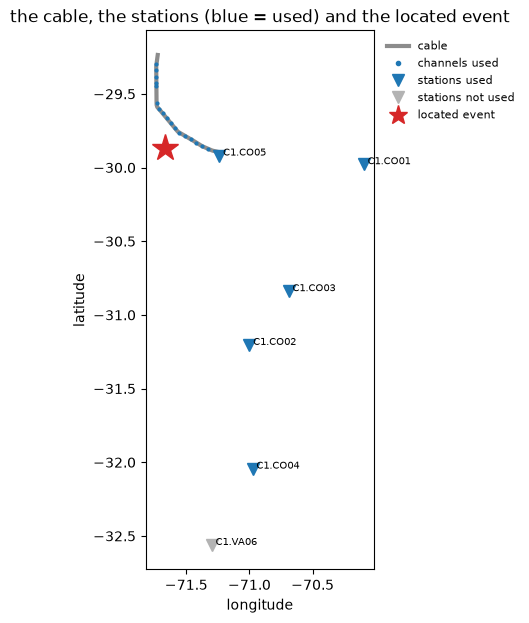

In [13]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

used = set(combined_picks.loc[combined_picks["assoc"], "id"])

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(
    cable["longitude"].values, cable["latitude"].values,
    "-", lw=3, c="0.55", zorder=1,
)
contributing = das_stations[das_stations["id"].isin(used)]
ax.plot(contributing["longitude"], contributing["latitude"], ".", ms=4, c="C0", zorder=2)

for _, station in stations.iterrows():
    ax.plot(
        station["longitude"],
        station["latitude"],
        "v",
        ms=9,
        c="C0" if station["id"] in used else "0.7",
        zorder=3,
    )
    ax.text(station["longitude"] + 0.03, station["latitude"], station["id"], fontsize=7)

ax.plot(event["longitude"], event["latitude"], "*", ms=20, c="C3", zorder=4)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("the cable, the stations (blue = used) and the located event")
ax.set_aspect(1 / np.cos(np.deg2rad(31)))
ax.legend(
    handles=[
        Line2D([], [], color="0.55", lw=3, label="cable"),
        Line2D([], [], marker=".", ls="none", ms=6, color="C0", label="channels used"),
        Line2D([], [], marker="v", ls="none", ms=8, color="C0", label="stations used"),
        Line2D([], [], marker="v", ls="none", ms=8, color="0.7", label="stations not used"),
        Line2D([], [], marker="*", ls="none", ms=14, color="C3", label="located event"),
    ],
    loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=8,
)
plt.show()

## Checking it arrival by arrival

A location is a hypothesis. The honest test is to predict every network
arrival from it and look at the residuals — the land picks are the ones the
fibre had no say in, so they are where the fit can be caught out:

In [14]:
from gamma.seismic_ops import calc_time

coords = combined_stations.set_index("id")


# time from the located hypocentre to each site, through the 1-D model
def travel_time(sites, phases):
    xyz = sites[["x(km)", "y(km)", "z(km)"]].to_numpy()
    hypo = np.tile([event["x(km)"], event["y(km)"], event["depth(km)"], 0.0], (len(xyz), 1))
    # `association` swapped config["eikonal"] for the travel-time tables it solved
    return calc_time(hypo, xyz, list(phases), eikonal=config["eikonal"]).ravel()


check = gamma_picks.copy()
check["phase"] = check["type"].str.upper()
sites = coords.loc[check["id"]]
check["hypo(km)"] = np.sqrt(
    (sites["x(km)"] - event["x(km)"]) ** 2
    + (sites["y(km)"] - event["y(km)"]) ** 2
    + (sites["z(km)"] - event["depth(km)"]) ** 2
).to_numpy()
check["predicted"] = origin + pd.to_timedelta(travel_time(sites, check["type"]), unit="s")
check["residual(s)"] = (check["timestamp"] - check["predicted"]).dt.total_seconds()
# the land picks are the first rows of the combined table, in order
check["used"] = combined_picks["assoc"].iloc[: len(check)].to_numpy()
check.sort_values("hypo(km)")[["id", "phase", "hypo(km)", "residual(s)", "used"]]

,id,phase,hypo(km),residual(s),used
9,C1.CO05,S,49.643315,-0.713453,True
8,C1.CO05,P,49.643315,-0.304603,True
5,C1.CO03,S,145.758383,-1.102711,True
4,C1.CO03,P,145.758383,-0.346621,True
0,C1.CO01,P,155.263620,0.717253,True
1,C1.CO01,S,155.263620,-0.474204,True
3,C1.CO02,S,163.860006,-0.091342,True
2,C1.CO02,P,163.860006,-0.165069,True
7,C1.CO04,S,251.924044,-0.468823,False
6,C1.CO04,P,251.924044,0.834481,True


This is what the 1-D model buys. Every real arrival on the network now sits
within about a second of prediction — both phases at `CO05`, `CO03`, `CO01`
and `CO02`, from 50 to 164 km, and `CO04`'s P at 252 km, which two constant
velocities had four seconds early. Nine of the twelve station picks join the
event; with the same tenth of the cable and a pair of constants it was six,
and the S arrivals at 150 km were the ones being thrown away.

Two things are still left out. `CO04`'s S is half a second off and did not
make the cut — a residual is not the criterion, the mixture's own weighting
is. And the two `VA06` picks are off by tens of seconds: at 302 km that
station recorded nothing and the picker labelled noise. Dropping those is
exactly what an associator is for.

## One figure

Time against position for every pick: the DAS channels by their distance
along the cable, the six land stations on a lane each below it. A pick is
coloured by phase where GaMMA associated it, faint where the decimation
never offered it, and grey where it was offered and rejected — which is the
per-channel noise and the two `VA06` picks the residual table already
flagged.
The lines are the arrivals predicted from the located hypocentre through the
same 1-D model, drawn as a moveout curve along the cable and as a tick on
each land lane.

The faint picks are the point of the subsample: the nine tenths GaMMA never
saw fall on the moveout drawn from the tenth it did, evenly spaced up the
whole cable.

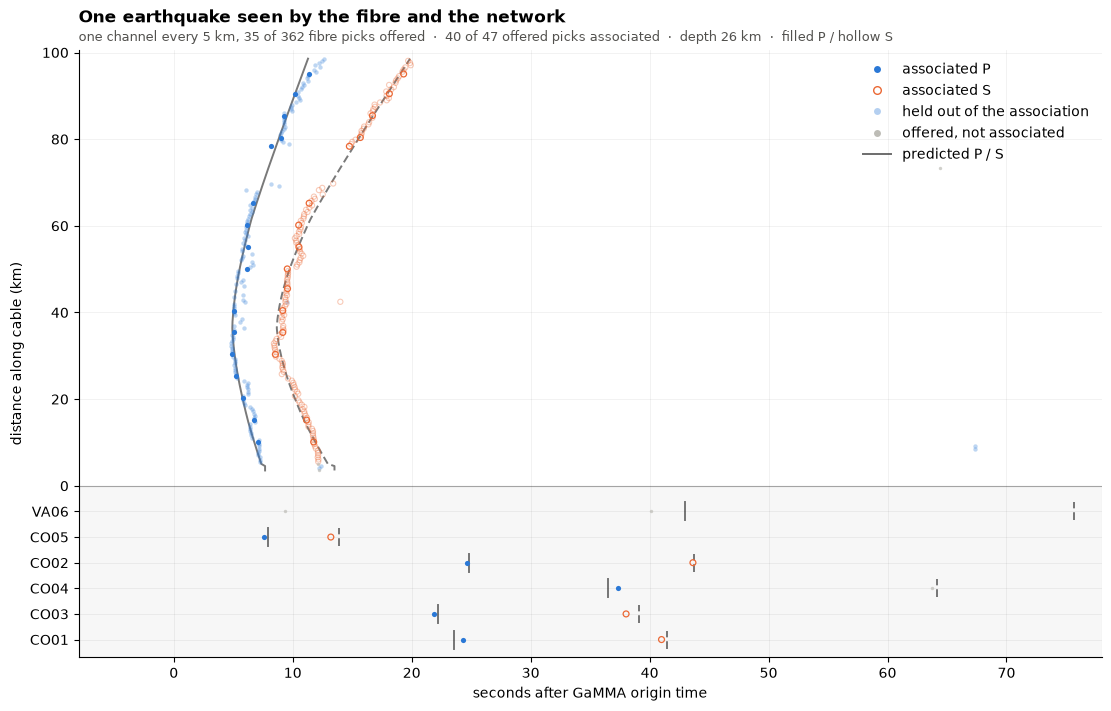

In [15]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# every pick, associated or not, offered to the association or held back
p = pd.concat(
    [
        combined_picks.assign(offered=True),
        held_out.assign(offered=False, assoc=False),
    ],
    ignore_index=True,
)
p["dt"] = (p["timestamp"] - origin).dt.total_seconds()
p["is_p"] = p["type"].str.upper().eq("P")

# --- a y position for every pick: km along the cable, or a lane per station -
geom = combined_stations.set_index("id")
is_das = geom.index.str.startswith("DAS.")
cable_km = pd.Series(
    geom.index[is_das].str.split(".").str[1].astype(float).to_numpy() / 1e3,
    index=geom.index[is_das],
)
land = geom[~is_das].sort_values("longitude")  # west to east
step = 0.06 * cable_km.max()
lane = {sid: -step * (k + 1) for k, sid in enumerate(land.index)}
p["y"] = p["id"].map(lambda s: lane.get(s, cable_km.get(s, np.nan)))

# --- arrivals predicted from the located hypocentre, on the 1-D model -----
tp = pd.Series(travel_time(geom, ["p"] * len(geom)), index=geom.index)
ts = pd.Series(travel_time(geom, ["s"] * len(geom)), index=geom.index)
order = cable_km.sort_values().index

# --- draw ---------------------------------------------------------------
INK, GREY, P_C, S_C = "#0b0b0b", "#bdbcb6", "#2a78d6", "#eb6834"
fig, ax = plt.subplots(figsize=(11, 7), layout="constrained")
ax.axhspan(min(lane.values()) - step, 0, color=INK, alpha=0.03, zorder=0)

ax.plot(tp[order], cable_km[order], color=INK, lw=1.4, alpha=0.55, zorder=2)
ax.plot(ts[order], cable_km[order], color=INK, lw=1.4, alpha=0.55, ls=(0, (4, 2)), zorder=2)
for sid, y in lane.items():
    for t, dash in ((tp[sid], "-"), (ts[sid], (0, (4, 2)))):
        ax.plot([t, t], [y - 0.35 * step, y + 0.35 * step], color=INK, lw=1.4, alpha=0.55, ls=dash)

held = p[~p["offered"]]
ax.scatter(
    held.loc[held["is_p"], "dt"], held.loc[held["is_p"], "y"],
    s=10, c=P_C, lw=0, alpha=0.3, zorder=3,
)
ax.scatter(
    held.loc[~held["is_p"], "dt"], held.loc[~held["is_p"], "y"],
    s=14, facecolors="none", edgecolors=S_C, lw=0.8, alpha=0.35, zorder=3,
)

missed = p[p["offered"] & ~p["assoc"]]
ax.scatter(missed["dt"], missed["y"], s=6, c=GREY, lw=0, alpha=0.7, zorder=4)

hit = p[p["assoc"]]
ax.scatter(hit.loc[hit["is_p"], "dt"], hit.loc[hit["is_p"], "y"], s=14, c=P_C, lw=0, zorder=5)
ax.scatter(
    hit.loc[~hit["is_p"], "dt"], hit.loc[~hit["is_p"], "y"],
    s=18, facecolors="none", edgecolors=S_C, lw=0.9, zorder=5,
)

ax.axhline(0, color=INK, lw=0.8, alpha=0.3)
pos = [t for t in ax.get_yticks() if t >= 0]
ax.set_yticks(pos + list(lane.values()))
ax.set_yticklabels([f"{t:g}" for t in pos] + [s.split(".")[-1] for s in lane])
ax.set_xlim(-8, 78)
ax.set_ylim(min(lane.values()) - 0.7 * step, cable_km.max() * 1.02)
ax.set_xlabel("seconds after GaMMA origin time")
ax.set_ylabel("distance along cable (km)")
ax.grid(True, color=INK, alpha=0.06, lw=0.6)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title(
    "One earthquake seen by the fibre and the network",
    loc="left", pad=20, fontweight="bold",
)
ax.text(
    0, 1.015,
    f"one channel every {spacing:.0f} km, {len(sample)} of {len(das_gamma_picks)} fibre picks offered  ·  "
    f"{int(p['assoc'].sum())} of {len(combined_picks)} offered picks associated  ·  "
    f"depth {event['depth(km)']:.0f} km  ·  filled P / hollow S",
    transform=ax.transAxes, fontsize=9, color="#52514e",
)
ax.legend(
    handles=[
        Line2D([], [], marker="o", ls="none", ms=5, mfc=P_C, mec="none", label="associated P"),
        Line2D([], [], marker="o", ls="none", ms=5.5, mfc="none", mec=S_C, mew=1, label="associated S"),
        Line2D([], [], marker="o", ls="none", ms=5, mfc=P_C, mec="none", alpha=0.35, label="held out of the association"),
        Line2D([], [], marker="o", ls="none", ms=5, mfc=GREY, mec="none", label="offered, not associated"),
        Line2D([], [], color=INK, lw=1.4, alpha=0.6, label="predicted P / S"),
    ],
    loc="upper right", frameon=False,
)
plt.show()